## Обучение с учителем. Задача регрессии

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

#### Чтение данных

In [2]:
data = pd.read_csv(f'../data/diamonds_filtered.csv')

data.head()

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190


#### Выделение целевого признака и предиктора

In [3]:
y = data['price']
x = data.drop(['price'], axis=1)

In [4]:
y[:5]

0    334
1    335
2    339
3    344
4    345
Name: price, dtype: int64

In [5]:
x[:5]

,carat,cut,color,clarity,depth,table,radius
0,0.29,4,2,4,62.4,58,2.100
1,0.31,2,1,2,63.3,58,2.170
2,0.30,2,1,3,64.0,55,2.125
3,0.31,5,1,2,62.2,54,2.175
4,0.32,4,6,1,60.9,58,2.190


#### Разделение данных на обучающую и тестовую выборки

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=81)

x_train

,carat,cut,color,clarity,depth,table,radius
16626,1.21,3,4,4,63.1,58,3.385
28087,0.30,5,5,4,61.6,57,2.165
28816,0.31,4,3,6,61.4,58,2.185
30464,0.41,5,5,4,60.8,56,2.400
38797,0.51,5,5,3,61.3,56,2.595
...,...,...,...,...,...,...,...
1009,0.81,4,5,3,61.3,60,3.000
3523,0.70,5,6,4,60.8,56,2.870
16331,1.03,2,6,5,63.3,59,3.200
4171,1.00,2,5,2,60.6,62,3.180


#### Масштабирование данных

In [7]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)     # считает среднее, отклонение и преобразует
x_test = scaler.transform(x_test)       # только преобразует (x - среднее) / отклонение

#### Cбор данных по ходу обучения различных моделей

In [8]:
results_list = []

def collect_metrics(model_name, model, x_test=x_test, y_test=y_test):
    y_pred = model.predict(x_test)
    
    return {
        'Model': model_name,
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4),
        'RMSE': round(sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAPE': round(sqrt(mean_absolute_percentage_error(y_test, y_pred)), 4), 
        'R2': round(model.score(x_test, y_test), 5)
    }

#### Построение графиков

In [9]:
def evaluate_model_visual(model_name, y_pred, y_test=y_test):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor='w')
    
    line_coords = [y_test.min(), y_test.max()]
    plt.plot(line_coords, line_coords, color='blue', linestyle='--', lw=2, label='Идеальные предсказания')
    
    plt.title(f'Анализ модели {model_name}')
    plt.xlabel('Реальные цены (Actual)')
    plt.ylabel('Предсказанные цены (Predicted)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

### Линейная регрессия

In [10]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(x_test)

#### Метрики качества

In [12]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 715.7342849673886
MSE: 1094671.312960932
RMSE: 1046.265412293139
MAPE: 0.6285430288129593
R^2: 0.9126883679986152


#### Значения весов

In [13]:
lr.coef_

array([ 5900.43180824,    57.86211668,   568.30857287,   779.09960723,
        -138.45111345,   -82.54400423, -2252.47496962])

#### Добавление результатов

In [14]:
results_list.append(collect_metrics(
    'Linear Regression',
    lr
))

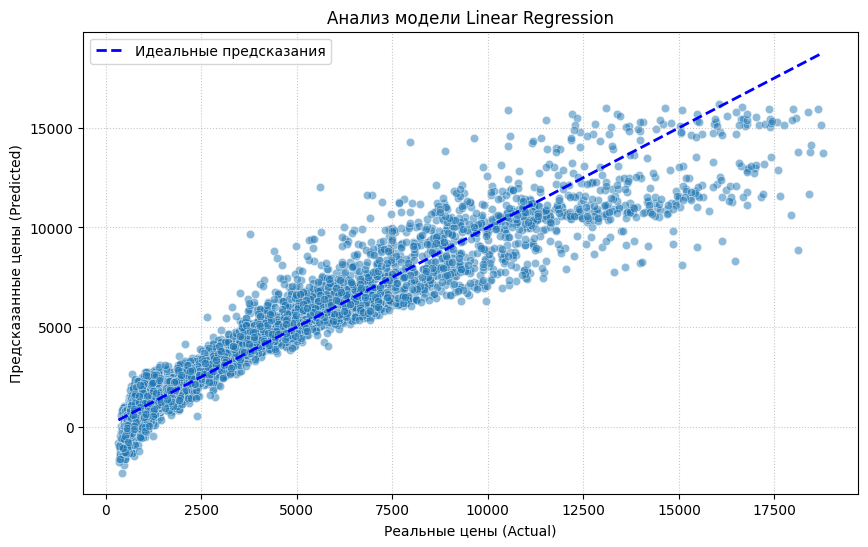

In [15]:
evaluate_model_visual('Linear Regression', y_pred)

**Анализ графика**

- Линейный тренд: Большинство точек выстроены вдоль красной пунктирной линии. Это подтверждает твой высокий R^2≈0.91. Модель хорошо уловила общую связь веса и цены.

- Проблема дорогих алмазов: после 12 500 (по оси Actual) облако точек начинает «разлетаться» и чаще оказывается ниже красной линии. Это значит, что на дорогих камнях модель начинает занижать цену. Линейной функции не хватает гибкости, чтобы описать элитные алмазы.

- Выбросы: в данных присутствуют аномалии, влияющие на MSE.

### Lasso (L1)

#### Обучение Lasso с задаными параметрами

In [16]:
lasso = Lasso(alpha=10, max_iter=10_000).fit(x_train, y_train)
y_pred = lasso.predict(x_test)

#### Метрики качества

In [17]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {lasso.score(x_test, y_test)}')

lasso.coef_

MAE: 729.7482212058276
MSE: 1113012.4626751232
RMSE: 1054.9940581231363
MAPE: 0.6373148693151239
R^2: 0.9112254670388776


array([ 5174.62373391,    60.91932642,   545.53574294,   784.34278807,
         -90.5512072 ,   -60.55628865, -1534.88058651])

#### Добавление результатов

In [18]:
results_list.append(collect_metrics(
    'Lasso',
    lasso
))

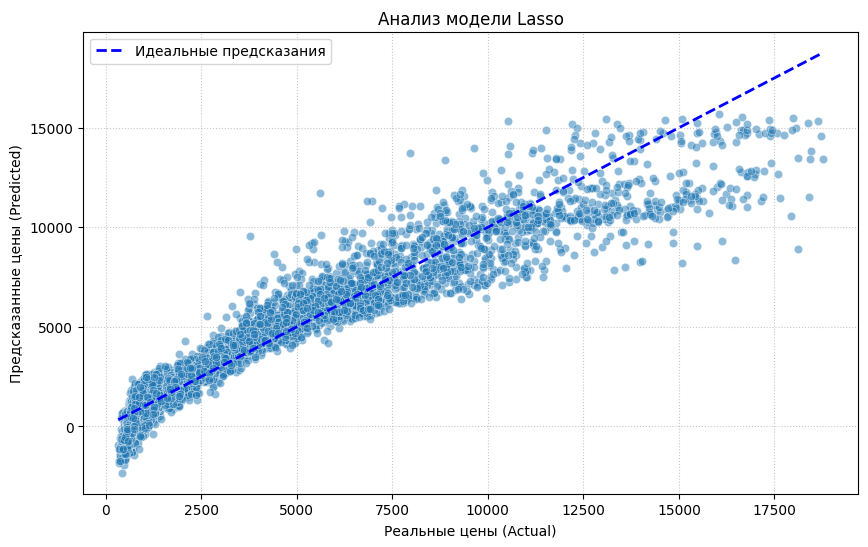

In [19]:
evaluate_model_visual('Lasso', y_pred)

#### Подбор гиперпараметра при помощи `GridSearchCV`

In [20]:
params = {
    'alpha' : np.arange(0.1, 1.1, 0.1)
}

params

{'alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}

In [21]:
grid_lasso = GridSearchCV(
    lasso,
    params,
    cv = 5,
)

grid_lasso.fit(x_train, y_train)
model = grid_lasso.best_estimator_
best_alpha = grid_lasso.best_params_['alpha']

print(f'Оптимальное значение гиперпараметра alpha = {best_alpha}')

Оптимальное значение гиперпараметра alpha = 0.1


In [22]:
y_pred = model.predict(x_test)

#### Метрики качества

In [23]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {grid_lasso.score(x_test, y_test)}')

model.coef_

MAE: 715.7998423202026
MSE: 1094707.7331420965
RMSE: 1046.2828169964832
MAPE: 0.6285910165387173
R^2: 0.9126854631034036


array([ 5893.09420798,    57.8931735 ,   568.07997343,   779.15422374,
        -137.96804897,   -82.32318322, -2245.22034516])

#### Добавление результатов

In [24]:
results_list.append(collect_metrics(
    'Lasso (GridSearchCV)',
    model
))

#### Подбор гиперпараметра при помощи `RandomizedSearchCV`

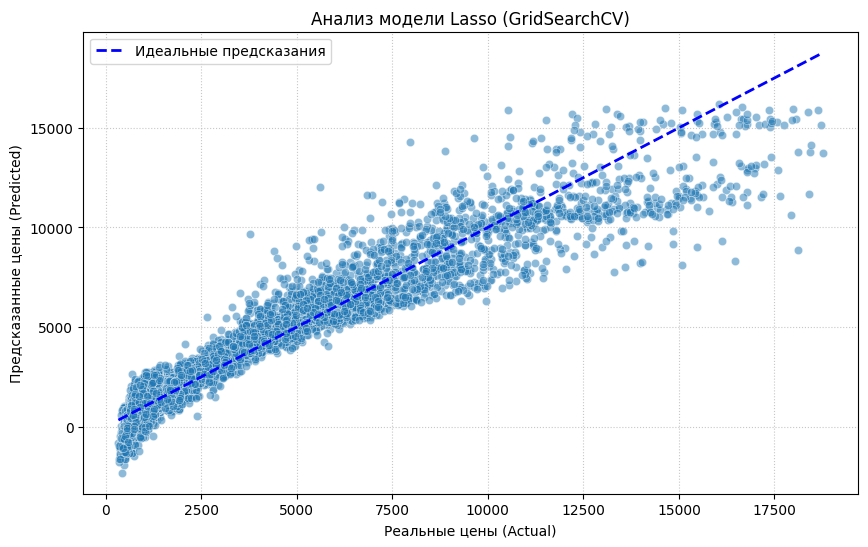

In [25]:
evaluate_model_visual('Lasso (GridSearchCV)', y_pred)

In [26]:
params = {'alpha' : np.arange(0.01, 1.1, 0.01)}
params

{'alpha': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
        0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
        0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
        0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
        0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
        0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
        0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
        0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
        0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
        1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09])}

In [27]:
random_lasso = RandomizedSearchCV(
    lasso,
    params,
    cv = 5,
    random_state=81
)

random_lasso.fit(x_train, y_train)
model = random_lasso.best_estimator_
best_alpha = random_lasso.best_params_['alpha']

print(f'Оптимальное значение гиперпараметра alpha = {best_alpha}')

Оптимальное значение гиперпараметра alpha = 0.12


In [28]:
y_pred = model.predict(x_test)

#### Метрики качества

In [29]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {random_lasso.score(x_test, y_test)}')

model.coef_

MAE: 715.8130899682142
MSE: 1094715.370809979
RMSE: 1046.2864668961265
MAPE: 0.6286006244511506
R^2: 0.9126848539184916


array([ 5891.62850315,    57.8993738 ,   568.03427343,   779.16509717,
        -137.87152888,   -82.27904057, -2243.77121634])

#### Добавление результатов

In [30]:
results_list.append(collect_metrics(
    'Lasso (RandomziedSearch)',
    model
))

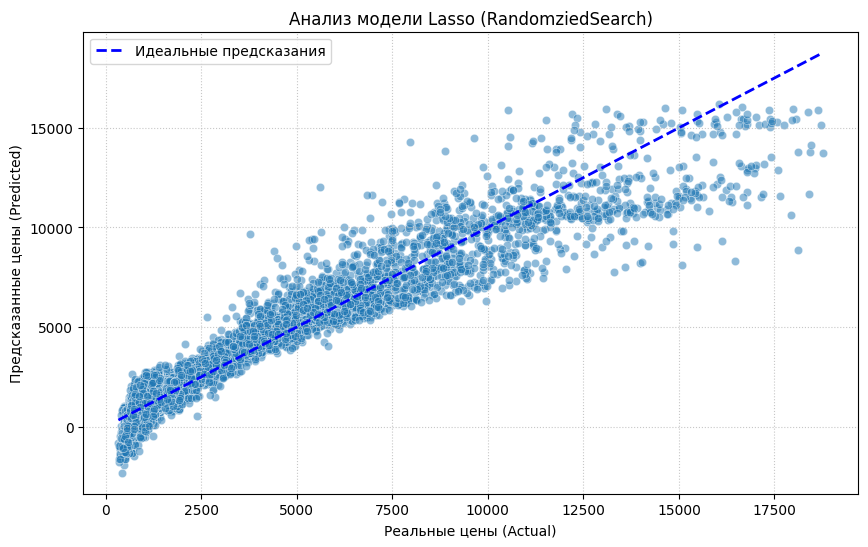

In [31]:
evaluate_model_visual('Lasso (RandomziedSearch)', y_pred)

### Ridge (L2)

#### Обучение Ridge с заданными параметрами

In [32]:
ridge = Ridge(alpha=100, max_iter=10_000).fit(x_train, y_train)
y_pred = ridge.predict(x_test)

#### Метрики качества

In [33]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {ridge.score(x_test, y_test)}')

ridge.coef_

MAE: 727.8438360632362
MSE: 1107438.6456628751
RMSE: 1052.3491082634484
MAPE: 0.6375002029924285
R^2: 0.9116700379836483


array([ 5309.84590726,    61.29376315,   556.21998415,   787.82859872,
        -108.57998909,   -73.54262355, -1668.09707965])

#### Добавление результатов

In [34]:
results_list.append(collect_metrics(
    'Ridge',
    ridge
))

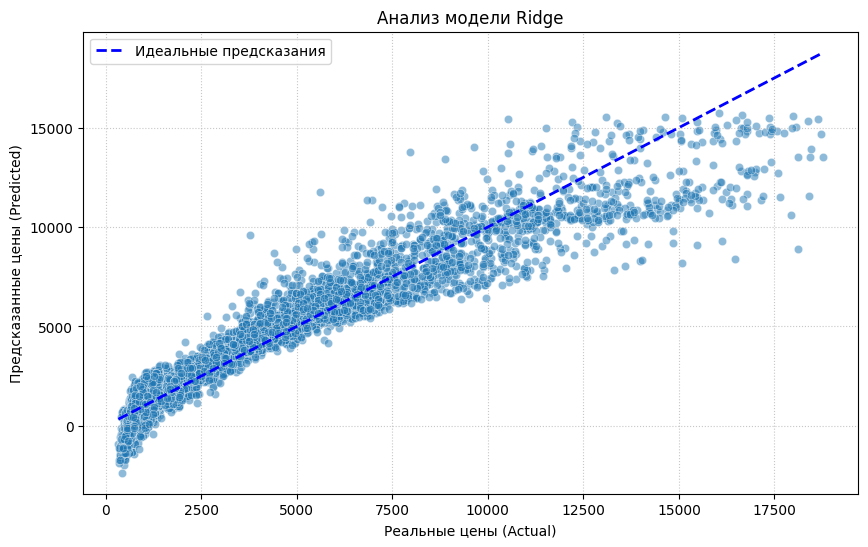

In [35]:
evaluate_model_visual('Ridge', y_pred)

#### Подбор гиперпараметра при помощи `GridSearchCV`

In [36]:
params = {
    'alpha' : np.arange(0.1, 1.1, 0.1)
}

In [37]:
grid_ridge = GridSearchCV(
    ridge,
    params,
    cv = 5,
)

grid_ridge.fit(x_train, y_train)
model = grid_ridge.best_estimator_
best_alpha = grid_ridge.best_params_['alpha']

print(f'Оптимальное значение гиперпараметра alpha = {best_alpha}') 

Оптимальное значение гиперпараметра alpha = 0.5


In [38]:
y_pred = model.predict(x_test)

#### Метрики качества

In [39]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {grid_ridge.score(x_test, y_test)}')

model.coef_

MAE: 715.7788860602099
MSE: 1094690.1464756439
RMSE: 1046.274412606771
MAPE: 0.6285829025680206
R^2: 0.9126868658263317


array([ 5896.98617309,    57.88227032,   568.24044386,   779.15407216,
        -138.27630933,   -82.49175402, -2249.06015847])

#### Добавление результатов

In [40]:
results_list.append(collect_metrics(
    'Ridge (GridSearchCV)',
    model
))

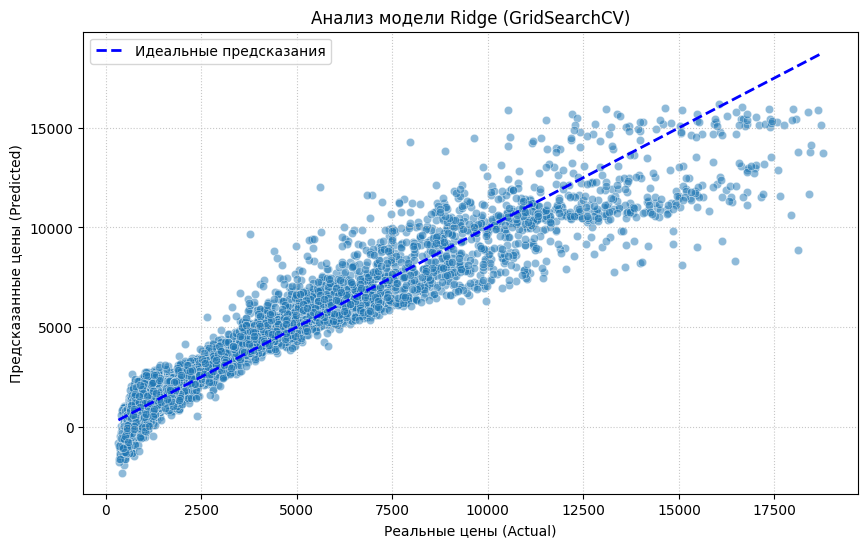

In [41]:
evaluate_model_visual('Ridge (GridSearchCV)', y_pred)

#### Подбор гиперпараметра при помощи `RandomizedSearchCV`

In [42]:
params = {
    'alpha' : np.arange(0.01, 1.1, 0.01)
}
params

{'alpha': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
        0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
        0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
        0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
        0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
        0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
        0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
        0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
        0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
        1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09])}

In [43]:
random_ridge = RandomizedSearchCV(
    ridge,
    params,
    cv = 5,
    random_state=81
)

random_ridge.fit(x_train, y_train)
model = random_ridge.best_estimator_
best_alpha = random_ridge.best_params_['alpha']

print(f'Оптимальное значение гиперпараметра alpha = {best_alpha}')

Оптимальное значение гиперпараметра alpha = 0.41000000000000003


In [44]:
y_pred = model.predict(x_test)

#### Метрики качества

In [45]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {random_ridge.score(x_test, y_test)}')

model.coef_

MAE: 715.7708642853904
MSE: 1094686.7105434774
RMSE: 1046.2727706212552
MAPE: 0.6285757316230803
R^2: 0.9126871398783155


array([ 5897.60596059,    57.87864526,   568.25270043,   779.14427785,
        -138.30775202,   -82.50115278, -2249.67439746])

#### Добавление результатов

In [46]:
results_list.append(collect_metrics(
    'Ridge (RandomziedSearch)',
    model
))

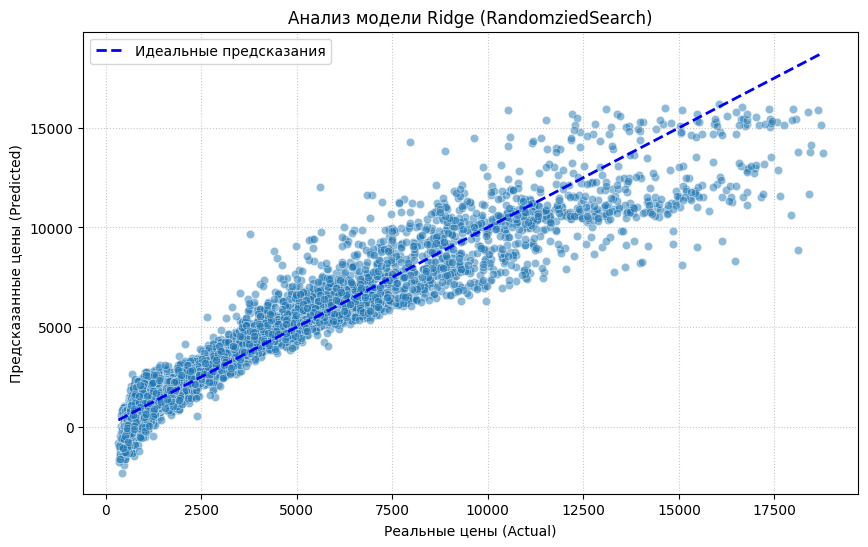

In [47]:
evaluate_model_visual('Ridge (RandomziedSearch)', y_pred)

### ElasticNet

#### Обучение ElasticNet с заданными параметрами

In [48]:
elastic = ElasticNet(alpha=0.5, max_iter=10_000).fit(x_train, y_train)
y_pred = elastic.predict(x_test)

#### Метрики качества

In [49]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {elastic.score(x_test, y_test)}')

elastic.coef_

MAE: 885.2567964513634
MSE: 1770757.2908932536
RMSE: 1330.6980464753278
MAPE: 0.6142282692158508
R^2: 0.8587633501347096


array([1778.28055752,   64.06471733,  291.08721122,  548.37297613,
         27.49092516,    4.85689247, 1324.43970552])

#### Добавление результатов

In [50]:
results_list.append(collect_metrics(
    'Elastic',
    elastic
))

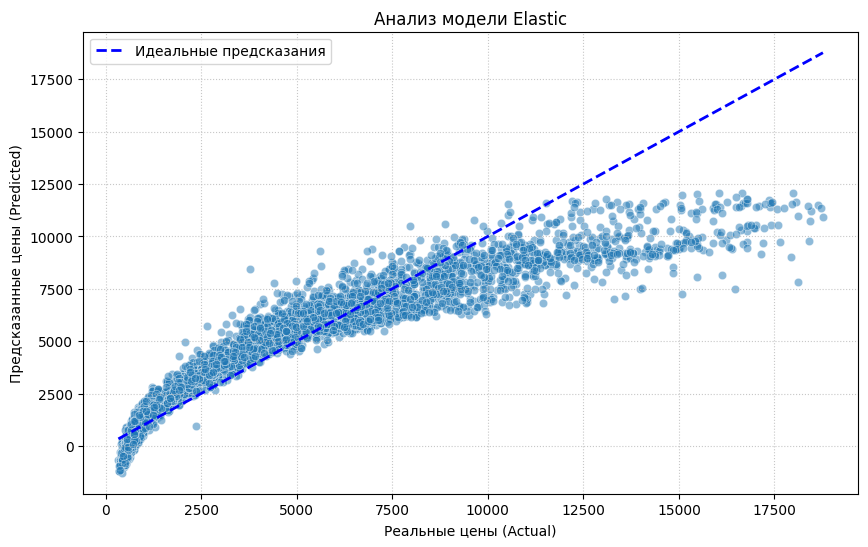

In [51]:
evaluate_model_visual('Elastic', y_pred)

#### Подбор гиперпараметра при помощи `Optuna`

In [52]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-5, 1e2)
    model = ElasticNet(alpha=alpha, random_state=81)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    return mse

In [53]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
model = ElasticNet(alpha=best_params['alpha'])
model.fit(x_train, y_train)

print(f'Оптимальное значение гиперпараметра alpha = {best_params}') 


[I 2026-03-11 11:37:20,503] A new study created in memory with name: no-name-10a09955-2fb5-4a7d-8de3-147a5bb06e86
/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_23572/960830692.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-5, 1e2)
[I 2026-03-11 11:37:20,544] Trial 0 finished with value: 1425419.1360862816 and parameters: {'alpha': 0.11740730991911612}. Best is trial 0 with value: 1425419.1360862816.
/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_23572/960830692.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-5, 1e2)
[I 2026-03-11 11:37:20,650] Tria

Оптимальное значение гиперпараметра alpha = {'alpha': 1.0010760352136348e-05}


In [54]:
y_pred = model.predict(x_test)

In [55]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {model.score(x_test, y_test)}')

model.coef_

MAE: 715.7527004503252
MSE: 1094679.0097133461
RMSE: 1046.2690904893186
MAPE: 0.6285594928594372
R^2: 0.9126877541010859


array([ 5899.00912784,    57.87043756,   568.2804416 ,   779.12209671,
        -138.37893177,   -82.5224253 , -2251.06501052])

#### Добавление результатов

In [56]:
results_list.append(collect_metrics(
    'ElasticNet (Optuna)',
    model
))

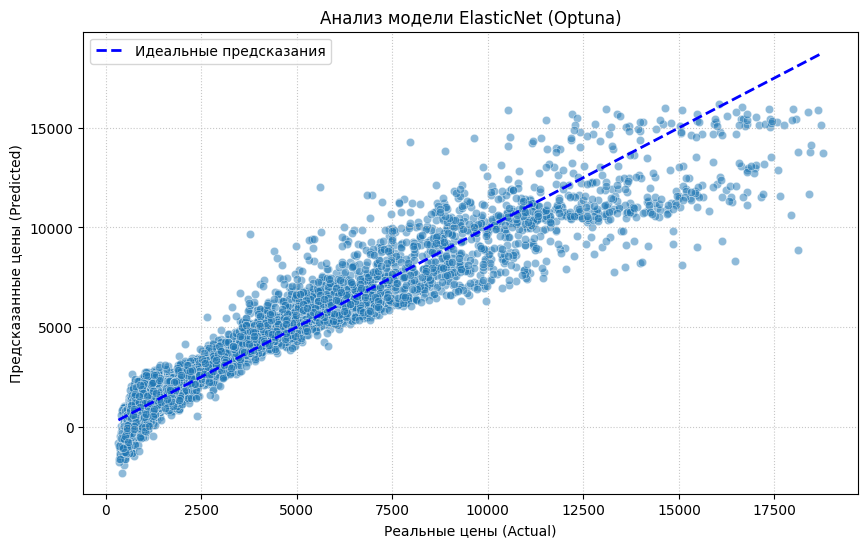

In [57]:
evaluate_model_visual('ElasticNet (Optuna)', y_pred)

In [58]:
results_df = pd.DataFrame(results_list)
results_df

,Model,MAE,MSE,RMSE,MAPE,R2
0,Linear Regression,715.7343,1.094671e+06,1046.2654,0.6285,0.91269
1,Lasso,729.7482,1.113012e+06,1054.9941,0.6373,0.91123
2,Lasso (GridSearchCV),715.7998,1.094708e+06,1046.2828,0.6286,0.91269
3,Lasso (RandomziedSearch),715.8131,1.094715e+06,1046.2865,0.6286,0.91268
4,Ridge,727.8438,1.107439e+06,1052.3491,0.6375,0.91167
5,Ridge (GridSearchCV),715.7789,1.094690e+06,1046.2744,0.6286,0.91269
6,Ridge (RandomziedSearch),715.7709,1.094687e+06,1046.2728,0.6286,0.91269
7,Elastic,885.2568,1.770757e+06,1330.6980,0.6142,0.85876
8,ElasticNet (Optuna),715.7527,1.094679e+06,1046.2691,0.6286,0.91269
